# Neural Network

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re
import os
import json

In [3]:
seed = 42

In [4]:
dataset = pd.read_csv("./datasets/thyroid0387_balanced.data", sep = ";", index_col="Unnamed: 0")

In [5]:
dataset.head()

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,...,T4U_value,FTI_value,TBG_value,ref_STMW,ref_SVHC,ref_SVHD,ref_SVI,ref_WEST,ref_other,diagnosis_group
0,29.0,False,False,False,False,False,False,False,True,False,...,0.964407,110.901257,32.308245,False,False,False,False,False,True,normal
1,29.0,False,False,False,False,False,False,False,False,False,...,0.972645,133.325191,21.728779,False,False,False,False,False,True,normal
2,41.0,False,False,False,False,False,False,False,False,True,...,0.776130,122.989623,11.000000,False,False,False,False,False,True,normal
3,36.0,False,False,False,False,False,False,False,False,False,...,1.015283,107.444888,26.000000,False,False,False,False,False,True,normal
4,32.0,False,False,False,False,False,False,False,False,False,...,0.818433,120.404426,36.000000,False,False,False,False,False,True,misc


In [6]:
label = LabelEncoder()
dataset["diagnosis_group"] = label.fit_transform(dataset["diagnosis_group"])

print(f"{dict(enumerate(label.classes_))}")

{0: 'antithyroid_treatment', 1: 'binding_protein', 2: 'general_health', 3: 'hyperthyroid', 4: 'hypothyroid', 5: 'misc', 6: 'normal', 7: 'replacement_therapy'}


In [7]:
numeric_col = dataset.select_dtypes(include = ["int64", "float64"]).columns

scaler = StandardScaler()
dataset[numeric_col] = scaler.fit_transform(dataset[numeric_col])

In [8]:
x = dataset.drop(columns=["diagnosis_group"])
x = x.astype("float32") # Convertimos los bool a int

y = dataset["diagnosis_group"]

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = seed)

In [10]:
print(f"X train: {x_train.shape}\nX test: {x_test.shape}\nY train: {y_train.shape}\nY test: {y_test.shape}")

X train: (36097, 28)
X test: (15471, 28)
Y train: (36097,)
Y test: (15471,)


In [11]:
x_train = torch.tensor(x_train.values, dtype = torch.float32)
x_test  = torch.tensor(x_test.values, dtype = torch.float32)
y_train = torch.tensor(y_train.values, dtype = torch.long)
y_test  = torch.tensor(y_test.values, dtype = torch.long)


## DataLoader

In [12]:
class MyDataLoader(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [20]:
train_dataset = MyDataLoader(x_train, y_train)
test_dataset = MyDataLoader(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size = 32, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size = 32, drop_last=True)

## Neural Network

In [21]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(28, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 8)
        )

    def forward(self, x):
        return self.layers(x)


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [27]:
xxnn = MLP()
xxnn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(xxnn.parameters(), lr = 0.001) 

In [28]:
n_epochs = 1000

test_accuracy = []
test_loss = []
train_accuracy = []
train_loss = []

# Variables para controlar si la red neuronal se ha quedado estancada
patience = 100
best_loss = float('inf')
trigger_times = 0

# Entrenamento
for epoch in range(n_epochs):

    xxnn.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    all_predictions = []
    all_targets = []

    for batch_x, batch_y in train_loader: 

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        

        outputs = xxnn(batch_x)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)
        prediction = torch.argmax(outputs, dim = 1)
        total_correct += (prediction == batch_y).sum().item()
        total_samples += batch_x.size(0)

    avg_train_loss = total_loss / total_samples
    avg_train_acc = total_correct / total_samples
    train_loss.append(avg_train_loss)
    train_accuracy.append(avg_train_acc)

    xxnn.eval()
    with torch.no_grad():

        total_loss = 0
        total_correct = 0
        total_samples = 0

        for batch_x, batch_y in test_loader:      

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            test_outputs = xxnn(batch_x)
            test_lo = criterion(test_outputs, batch_y)
            
            total_loss += test_lo.item() * batch_x.size(0)
            test_prediction = torch.argmax(test_outputs, dim = 1)
            total_correct += (test_prediction == batch_y).sum().item()
            total_samples += batch_x.size(0)

            all_predictions.append(test_prediction)
            all_targets.append(batch_y)
            
        avg_test_loss = total_loss / total_samples
        avg_test_acc = total_correct / total_samples
        test_loss.append(avg_test_loss)
        test_accuracy.append(avg_test_acc)
    
    
    y_true = torch.cat(all_targets).cpu().numpy()
    y_pred = torch.cat(all_predictions).cpu().numpy()

    if avg_test_loss < best_loss:
        best_loss = avg_test_loss
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Stoping at epoch {epoch + 1}")
            break
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{n_epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, Train Acc: {avg_train_acc:.2%}, Test Acc: {avg_test_acc:.2%}")


Epoch 10/1000, Train Loss: 0.1084, Test Loss: 0.0433, Train Acc: 96.39%, Test Acc: 98.75%
Epoch 20/1000, Train Loss: 0.0904, Test Loss: 0.0350, Train Acc: 97.06%, Test Acc: 98.96%
Epoch 30/1000, Train Loss: 0.0810, Test Loss: 0.0337, Train Acc: 97.28%, Test Acc: 98.96%
Epoch 40/1000, Train Loss: 0.0748, Test Loss: 0.0307, Train Acc: 97.57%, Test Acc: 99.04%
Epoch 50/1000, Train Loss: 0.0715, Test Loss: 0.0292, Train Acc: 97.59%, Test Acc: 99.10%
Epoch 60/1000, Train Loss: 0.0691, Test Loss: 0.0292, Train Acc: 97.74%, Test Acc: 99.11%
Epoch 70/1000, Train Loss: 0.0663, Test Loss: 0.0278, Train Acc: 97.82%, Test Acc: 99.20%
Epoch 80/1000, Train Loss: 0.0626, Test Loss: 0.0277, Train Acc: 97.92%, Test Acc: 99.13%
Epoch 90/1000, Train Loss: 0.0616, Test Loss: 0.0260, Train Acc: 97.93%, Test Acc: 99.20%
Epoch 100/1000, Train Loss: 0.0571, Test Loss: 0.0301, Train Acc: 98.10%, Test Acc: 99.07%
Epoch 110/1000, Train Loss: 0.0587, Test Loss: 0.0273, Train Acc: 98.09%, Test Acc: 99.09%
Epoch 12

Score F1: 0.9927347519048556


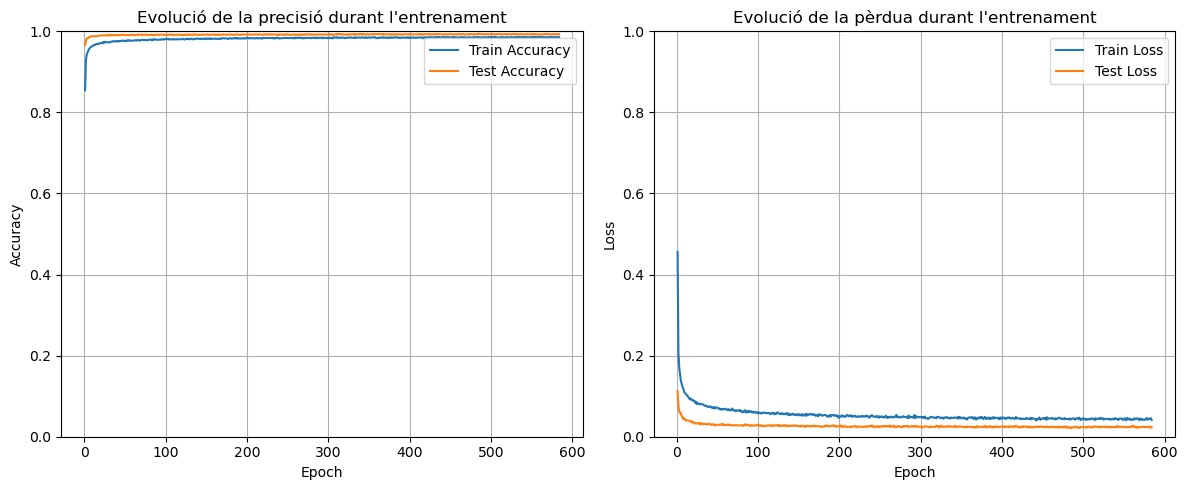

In [29]:
print(f"Score F1: {f1_score(y_true, y_pred, average = 'weighted')}")

epochs = range(1, len(train_accuracy) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracy, label='Train Accuracy')
plt.plot(epochs, test_accuracy, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Evolució de la precisió durant l\'entrenament')
plt.legend()
plt.grid(True)
plt.ylim(0, 1)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, test_loss, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Evolució de la pèrdua durant l\'entrenament')
plt.legend()
plt.grid(True)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## Model evaluation

Accuracy: 0.9927536231884058
F1 score: 0.9927347519048556


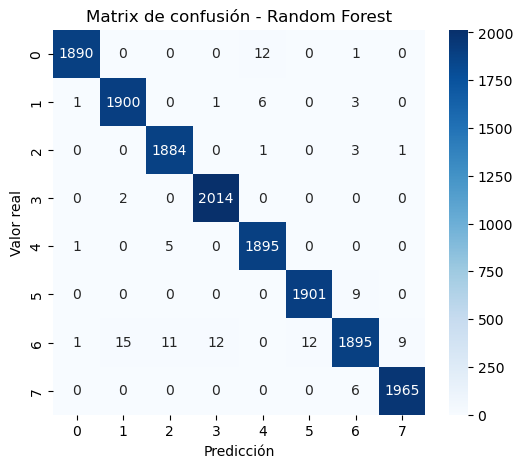

In [ ]:
print(f"Accuracy: {accuracy_score(y_true, y_pred)}")
print(f"F1 score: {f1_score(y_true, y_pred, average = 'weighted')}")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matrix de confusión - Neural Network')
plt.show()


## Saving model

In [33]:
joblib.dump(xxnn, "./models_saved/xxnn.json")

['./models_saved/xxnn.json']